In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src import file_io as fio
import matplotlib.pyplot as plt
import numpy as np
import dask.dataframe as dd
import hvplot.dask
import pandas as pd
import itertools
from scipy.constants import year
from scipy.stats import gaussian_kde

import mpl_scatter_density # adds projection='scatter_density'
from matplotlib.colors import LinearSegmentedColormap
# Make the norm object to define the image stretch
from astropy.visualization import LogStretch
from astropy.visualization.mpl_normalize import ImageNormalize
norm = ImageNormalize(vmin=0., vmax=1000, stretch=LogStretch())

In [2]:
solar_data = pd.read_parquet('/home/chuang/Projects/ephin-predict/datasets/test_predictions_1996/test_predictions_1996.parquet')
solar_data.columns = [
    'log1p_delta_A',
    'log1p_delta_ABC',
    'status_opp_err_frame',
    'status_fma',
    'status_fmb',
    'log1p_delta_D',
    'log1p_delta_E',
    'pred_log1p_delta_D',
    'pred_log1p_delta_E'
]

In [3]:
ABC = np.expm1(solar_data['log1p_delta_ABC'])
A = np.expm1(solar_data['log1p_delta_A'])
D = np.expm1(solar_data['log1p_delta_D'])
E = np.expm1(solar_data['log1p_delta_E'])
D_pred = np.expm1(solar_data['pred_log1p_delta_D'])
E_pred = np.expm1(solar_data['pred_log1p_delta_E'])

In [4]:
total_energy = ABC.add(D).add(E)
total_energy_pred = ABC.add(D_pred).add(E_pred)


In [5]:
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', [
    (0, 'white'),
    (1e-20, 'indigo'),
    (0.2, 'navy'),
    (0.4, 'springgreen'),
    (0.6, 'yellow'),
    (0.8, 'orange'),
    (1, 'red'),
], N=256)

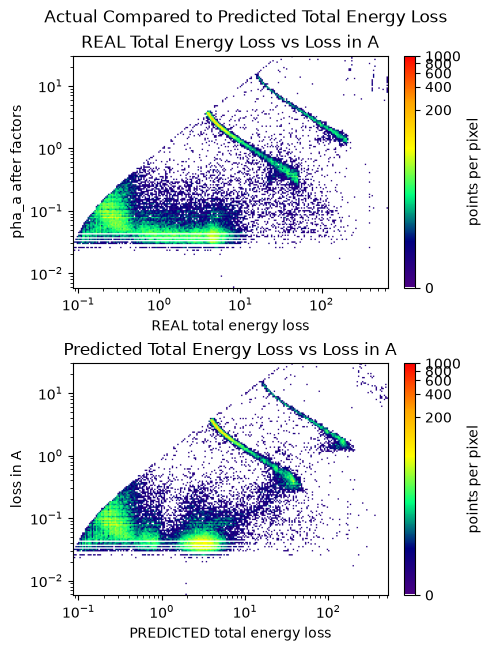

In [15]:
fig = plt.figure(layout='constrained')
fig.set_figheight(6.4)
fig.set_figwidth(4.8)

ax1 = fig.add_subplot(2, 1, 1, projection='scatter_density')
ax1.set_xlabel("REAL total energy loss")
ax1.set_xscale("log")
ax1.set_ylabel("loss in A")
ax1.set_yscale("log")
ax1.set_title('REAL Total Energy Loss vs Loss in A')
# try a log normed density map
density1 = ax1.scatter_density(total_energy, A, norm=norm, cmap=custom_cmap)
fig.colorbar(density1, ax=ax1, label='points per pixel')

ax2 = fig.add_subplot(2, 1, 2, projection='scatter_density')
ax2.set_xlabel("PREDICTED total energy loss")
ax2.set_xscale("log")
ax2.set_ylabel("loss in A")
ax2.set_yscale("log")
ax2.set_title('Predicted Total Energy Loss vs Loss in A')
density2 = ax2.scatter_density(total_energy_pred, A, norm=norm, cmap=custom_cmap)
fig.colorbar(density2, ax=ax2, label='points per pixel')

fig.suptitle("Actual Compared to Predicted Total Energy Loss")

plt.savefig('/home/chuang/Projects/ephin-predict/outputs/graphs/random_forest_v0_sim_vs_real.png')
plt.show()
plt.close(fig)